## Part 1: Environment Setup & Validation

### 1.1 Installation

In [1]:
%pip install opencv-python matplotlib pandas numpy -q

### 1.2 Import & Validate

OpenCV version: 5.0.0
NumPy version: 2.1.3
Pandas version: 2.2.3


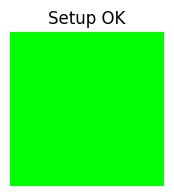

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

_test = np.zeros((10, 10, 3), dtype=np.uint8)
_test[:, :] = (0, 255, 0)
plt.figure(figsize=(2, 2))
plt.imshow(_test)
plt.title("Setup OK")
plt.axis('off')
plt.show()


## Part 2: Python Data Structures & Logic

### Task 1: Object-Oriented Grocery Manager

In [4]:
class GroceryManager:

    def __init__(self):
        self.items = {}

    def add_item(self, item, quantity, price):
        if quantity <= 0 or price < 0:
            print(f"Error: Invalid quantity or price for '{item}'.")
            return
        if item in self.items:
            self.items[item]["quantity"] += quantity
            self.items[item]["price"] = price
            new_qty = self.items[item]["quantity"]
            print(f"Updated '{item}': quantity={new_qty}, price=${price:.2f}")
        else:
            self.items[item] = {"quantity": quantity, "price": price}
            print(f"Added '{item}': quantity={quantity}, price=${price:.2f}")

    def remove_item(self, item):
        try:
            del self.items[item]
            print(f"Removed '{item}' from the list.")
        except KeyError:
            print(f"Error: '{item}' does not exist in the grocery list.")

    def view_list(self):
        if not self.items:
            print("Grocery list is empty.")
            return
        header = f"{'Item':<15}{'Quantity':<10}{'Price':<10}{'Subtotal':<10}"
        print(header)
        for item, details in self.items.items():
            qty = details["quantity"]
            price = details["price"]
            subtotal = qty * price
            row = f"{item:<15}{qty:<10}${price:<9.2f}${subtotal:<9.2f}"
            print(row)

    def calculate_total(self):
        total = sum(d["quantity"] * d["price"] for d in self.items.values())
        return total


In [5]:
# Test the GroceryManager
manager = GroceryManager()
manager.add_item("Apples", 6, 0.50)
manager.add_item("Milk", 2, 3.20)
manager.add_item("Bread", 1, 2.75)
manager.view_list()
print(f"\nTotal cost: ${manager.calculate_total():.2f}\n")

manager.remove_item("Milk")
manager.remove_item("Eggs")
manager.view_list()


Added 'Apples': quantity=6, price=$0.50
Added 'Milk': quantity=2, price=$3.20
Added 'Bread': quantity=1, price=$2.75
Item           Quantity  Price     Subtotal  
Apples         6         $0.50     $3.00     
Milk           2         $3.20     $6.40     
Bread          1         $2.75     $2.75     

Total cost: $12.15

Removed 'Milk' from the list.
Error: 'Eggs' does not exist in the grocery list.
Item           Quantity  Price     Subtotal  
Apples         6         $0.50     $3.00     
Bread          1         $2.75     $2.75     


### Task 2: Advanced Student Record System

In [6]:
students = {
    "S001": {"Name": "Ayesha Khan", "Major": "Computer Science", "Grades": [88, 92, 79]},
    "S002": {"Name": "Bilal Ahmed", "Major": "Electrical Engineering", "Grades": [95, 91, 89]},
    "S003": {"Name": "Sara Malik", "Major": "Computer Science", "Grades": [72, 68, 75]},
    "S004": {"Name": "Usman Tariq", "Major": "Mechanical Engineering", "Grades": [84, 80, 88]},
    "S005": {"Name": "Hina Riaz", "Major": "Electrical Engineering", "Grades": [90, 94, 97]},
}


def top_student(records):
    """Returns the name of the student with the highest average grade."""
    best_name, best_avg = None, -1
    for info in records.values():
        avg = sum(info["Grades"]) / len(info["Grades"])
        if avg > best_avg:
            best_avg = avg
            best_name = info["Name"]
    return best_name, best_avg


def search_by_major(records, major):
    """Prints all students enrolled in the given major."""
    matches = [info["Name"] for info in records.values() if info["Major"].lower() == major.lower()]
    if matches:
        print(f"Students in {major}:")
        for name in matches:
            print(f"  - {name}")
    else:
        print(f"No students found in major: {major}")


In [7]:
name, avg = top_student(students)
print(f"Top student: {name} (average grade: {avg:.2f})\n")

search_by_major(students, "Computer Science")
print()
search_by_major(students, "Civil Engineering")


Top student: Hina Riaz (average grade: 93.67)

Students in Computer Science:
  - Ayesha Khan
  - Sara Malik

No students found in major: Civil Engineering


## Part 3: Core Computer Vision & Matplotlib

In [ ]:
rng = np.random.default_rng(42)
img1 = np.zeros((600, 600, 3), dtype=np.uint8)
for y in range(600):
    img1[y, :, 0] = int(255 * y / 600)          # Blue channel gradient (BGR order)
    img1[y, :, 2] = int(255 * (600 - y) / 600)  # Red channel gradient
cv2.circle(img1, (300, 300), 150, (0, 215, 255), -1)   # face-like circle (BGR: orange)
cv2.circle(img1, (250, 260), 20, (20, 20, 20), -1)     # left eye
cv2.circle(img1, (350, 260), 20, (20, 20, 20), -1)     # right eye
cv2.ellipse(img1, (300, 340), (60, 30), 0, 0, 180, (20, 20, 20), 4)  # smile
cv2.imwrite("sample1.jpeg", img1)

# sample2.jpeg: different colorful pattern (for masking task)
img2 = np.zeros((600, 600, 3), dtype=np.uint8)
img2[:, :] = (40, 40, 40)
for i in range(0, 600, 40):
    cv2.line(img2, (i, 0), (i, 600), (255, 100, 0), 4)
    cv2.line(img2, (0, i), (600, i), (0, 200, 255), 4)
cv2.imwrite("sample2.jpeg", img2)

# document.jpeg: high-contrast "document-like" image for thresholding
doc = np.full((600, 600), 255, dtype=np.uint8)
cv2.putText(doc, "SAMPLE DOCUMENT", (60, 150), cv2.FONT_HERSHEY_SIMPLEX, 1.4, (0,), 3)
cv2.putText(doc, "Lorem ipsum dolor sit amet,", (60, 250), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,), 2)
cv2.putText(doc, "consectetur adipiscing elit.", (60, 300), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,), 2)
cv2.rectangle(doc, (60, 350), (540, 500), (0,), 2)
# add a bit of noise/shadow gradient to make adaptive thresholding meaningful
noise_gradient = np.tile(np.linspace(0, 60, 600).astype(np.uint8), (600, 1))
doc = cv2.subtract(doc, noise_gradient)
cv2.imwrite("document.jpeg", doc)


Created sample1.jpeg, sample2.jpeg, and document.jpeg in the working directory.


### Task 3: Safe Image Loading & RGB Visualization

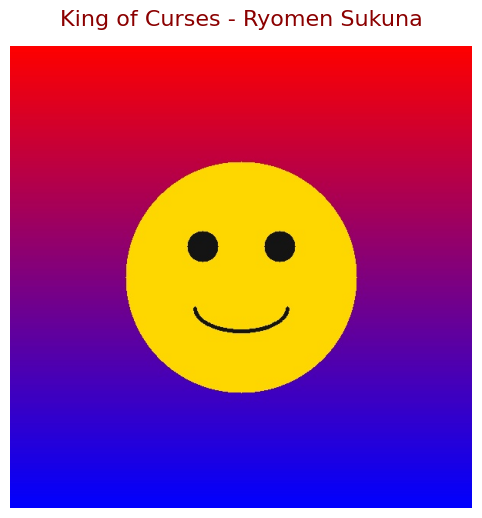

In [9]:
image_path = 'sample1.jpeg'  # change this to your own filename if you upload an image

image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.title('King of Curses - Ryomen Sukuna', fontsize=16, color='darkred', pad=15)
    plt.show()


### Task 4: Interactive Geometry & Blank Canvas

Canvas center coordinates: (400, 400)


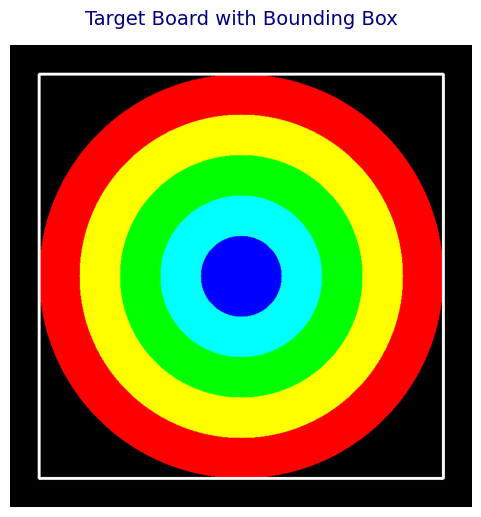

In [10]:
canvas = np.zeros((800, 800, 3), dtype=np.uint8)

center = (400, 400)
colors = [(0, 0, 255), (0, 255, 255), (0, 255, 0), (255, 255, 0), (255, 0, 0)]  # BGR, alternating
radii = [350, 280, 210, 140, 70]

for radius, color in zip(radii, colors):
    cv2.circle(canvas, center, radius, color, thickness=-1)

# Bounding box around the outermost circle
outer_radius = radii[0]
top_left = (center[0] - outer_radius, center[1] - outer_radius)
bottom_right = (center[0] + outer_radius, center[1] + outer_radius)
cv2.rectangle(canvas, top_left, bottom_right, (255, 255, 255), 3)

print(f"Canvas center coordinates: {center}")

canvas_rgb = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.imshow(canvas_rgb)
plt.axis('off')
plt.title('Target Board with Bounding Box', fontsize=14, color='navy', pad=15)
plt.show()


### Task 5: Advanced Blurring & NumPy ROI Extraction

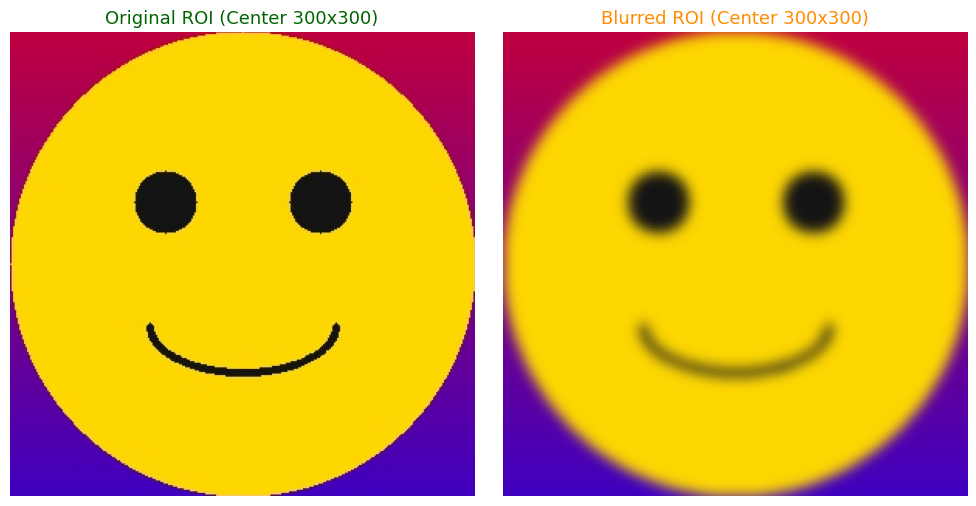

In [11]:
image_path = 'sample1.jpeg'  # swap for a high-resolution image of your own

image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Heavy Gaussian Blur
    blurred_rgb = cv2.GaussianBlur(image_rgb, (25, 25), 0)

    # Extract a 300x300 ROI from the exact center of both images
    h, w, _ = image_rgb.shape
    cy, cx = h // 2, w // 2
    half = 150  # half of 300

    roi_original = image_rgb[cy - half:cy + half, cx - half:cx + half]
    roi_blurred = blurred_rgb[cy - half:cy + half, cx - half:cx + half]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(roi_original)
    axes[0].axis('off')
    axes[0].set_title('Original ROI (Center 300x300)', fontsize=13, color='darkgreen')

    axes[1].imshow(roi_blurred)
    axes[1].axis('off')
    axes[1].set_title('Blurred ROI (Center 300x300)', fontsize=13, color='darkorange')

    plt.tight_layout()
    plt.show()


### Task 6: Alpha Blending & Typography

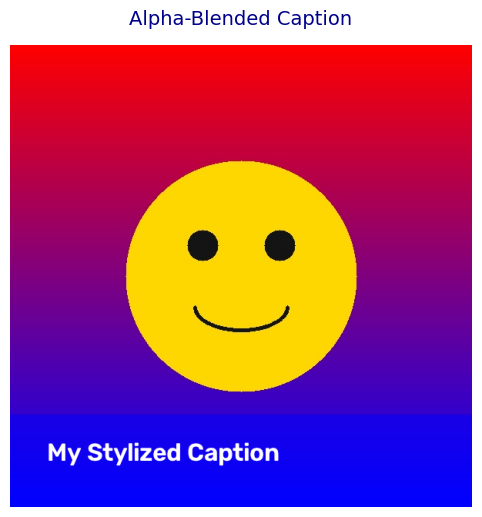

In [12]:
image_path = 'sample1.jpeg'

image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found.")
else:
    h, w, _ = image.shape
    overlay = image.copy()

    # Solid blue rectangle covering the bottom 20% of the image
    band_height = int(h * 0.20)
    cv2.rectangle(overlay, (0, h - band_height), (w, h), (255, 0, 0), -1)  # BGR blue

    alpha = 0.5  # transparency factor
    blended = cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0)

    # Add title text over the transparent box
    text = "My Stylized Caption"
    cv2.putText(blended, text, (int(w * 0.08), h - band_height // 2),
                cv2.FONT_HERSHEY_SIMPLEX, 1.1, (255, 255, 255), 2, cv2.LINE_AA)

    blended_rgb = cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    plt.imshow(blended_rgb)
    plt.axis('off')
    plt.title('Alpha-Blended Caption', fontsize=14, color='darkblue', pad=15)
    plt.show()


### Task 7: Matrix-Based Rotation & Adaptive Thresholding

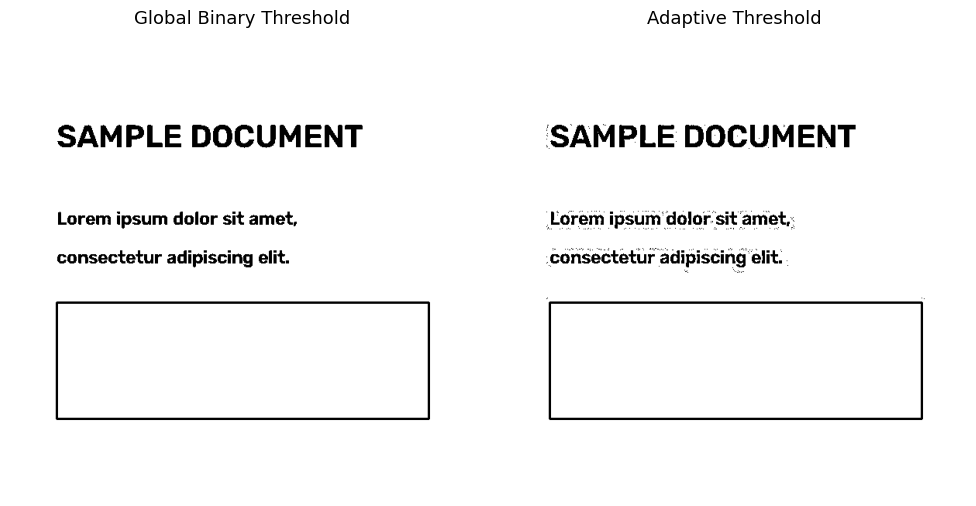

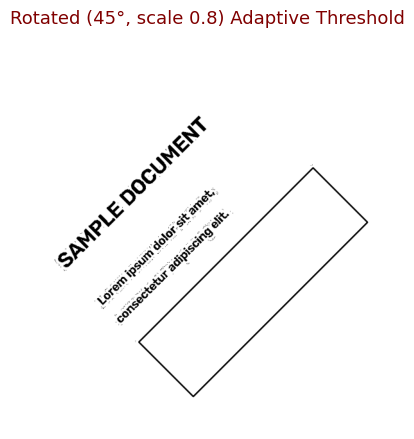

In [13]:
image_path = 'document.jpeg'

gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if gray is None:
    print("Error: Image not found.")
else:
    # Global Binary Thresholding
    _, global_thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    # Adaptive Thresholding
    adaptive_thresh = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(global_thresh, cmap='gray')
    axes[0].axis('off')
    axes[0].set_title('Global Binary Threshold', fontsize=13, color='black')

    axes[1].imshow(adaptive_thresh, cmap='gray')
    axes[1].axis('off')
    axes[1].set_title('Adaptive Threshold', fontsize=13, color='black')
    plt.tight_layout()
    plt.show()

    (h, w) = adaptive_thresh.shape
    center = (w // 2, h // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, 45, 0.8)
    rotated = cv2.warpAffine(adaptive_thresh, rotation_matrix, (w, h),
                              borderValue=255)

    plt.figure(figsize=(5, 5))
    plt.imshow(rotated, cmap='gray')
    plt.axis('off')
    plt.title('Rotated (45°, scale 0.8) Adaptive Threshold', fontsize=13, color='maroon', pad=15)
    plt.show()


### Task 8: Masking with Bitwise Logic

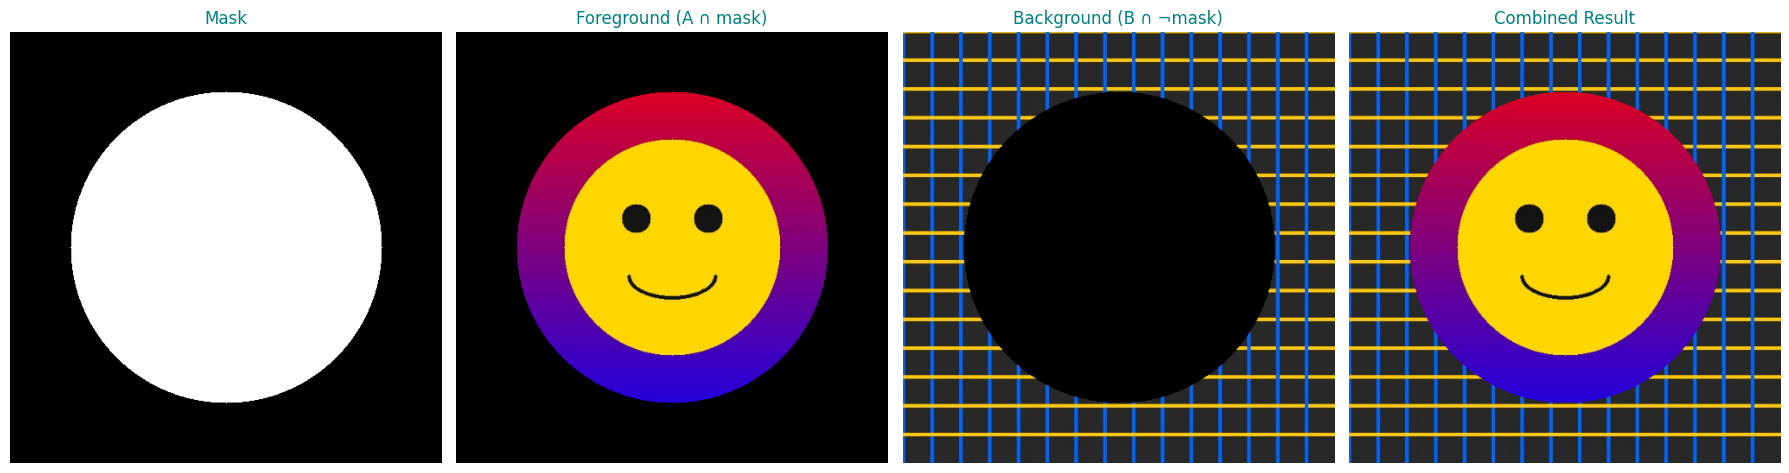

In [14]:
img_a = cv2.imread('sample1.jpeg')
img_b = cv2.imread('sample2.jpeg')

if img_a is None or img_b is None:
    print("Error: One or both images not found.")
else:
    size = (500, 500)
    img_a = cv2.resize(img_a, size)
    img_b = cv2.resize(img_b, size)

    # Binary mask: black background with a thick white circle in the center
    mask = np.zeros(size[::-1], dtype=np.uint8)
    cv2.circle(mask, (size[0] // 2, size[1] // 2), 180, 255, -1)

    # Cut the circle shape out of image A
    fg = cv2.bitwise_and(img_a, img_a, mask=mask)

    # Invert the mask and cut out the background from image B
    inverse_mask = cv2.bitwise_not(mask)
    bg = cv2.bitwise_and(img_b, img_b, mask=inverse_mask)

    # Combine foreground circle (from A) and background (from B)
    combined = cv2.bitwise_or(fg, bg)

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    titles = ['Mask', 'Foreground (A ∩ mask)', 'Background (B ∩ ¬mask)', 'Combined Result']
    images_to_show = [mask, fg, bg, combined]
    cmaps = ['gray', None, None, None]

    for ax, img, title, cmap in zip(axes, images_to_show, titles, cmaps):
        if cmap == 'gray':
            ax.imshow(img, cmap='gray')
        else:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.axis('off')
        ax.set_title(title, fontsize=12, color='teal')

    plt.tight_layout()
    plt.show()


### Task 9: Statistical Image Profiling with Pandas

In [15]:
image_path = 'sample1.jpeg'

image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    red_channel = image_rgb[:, :, 0].flatten()
    green_channel = image_rgb[:, :, 1].flatten()
    blue_channel = image_rgb[:, :, 2].flatten()

    df = pd.DataFrame({
        'Red': red_channel,
        'Green': green_channel,
        'Blue': blue_channel
    })

    print("Pixel-value statistical summary:")
    print(df.describe())


Pixel-value statistical summary:
                 Red          Green           Blue
count  360000.000000  360000.000000  360000.000000
mean      150.012311      40.533019     102.231867
std        88.279893      83.584883      87.651191
min         0.000000       0.000000       0.000000
25%        61.000000       0.000000      16.000000
50%       169.000000       0.000000      80.000000
75%       238.000000       1.000000     192.000000
max       255.000000     224.000000     254.000000
